In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("../data/Mall_Customers.csv")
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [3]:
print(df.columns)

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')


In [4]:
print(df.shape)

(200, 5)


In [5]:
print(df.info)

<bound method DataFrame.info of      CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]>


In [6]:
print(df.dtypes)

CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object


In [7]:
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [8]:
print(df.describe())

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


In [9]:
print(df.duplicated().sum())

0


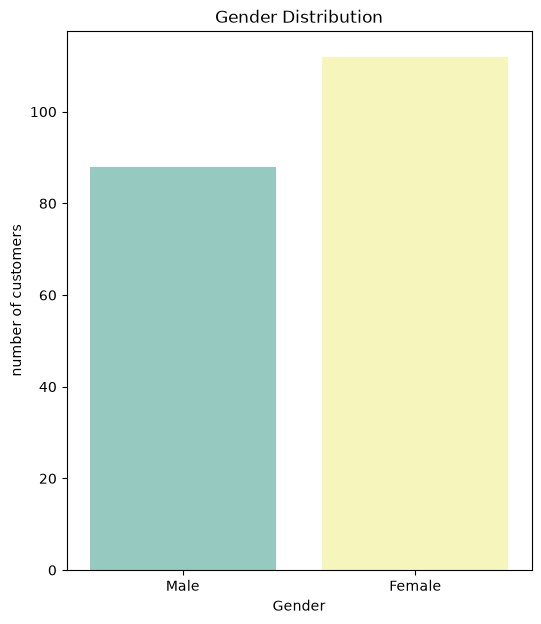

In [30]:

plt.figure(figsize=(6,7))
sns.countplot(
    data=df,
    x="Gender",
    hue="Gender",
    palette="Set3"
    
)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("number of customers")
plt.savefig("../images/gender_countplot.png", dpi=300, bbox_inches="tight")
plt.show()

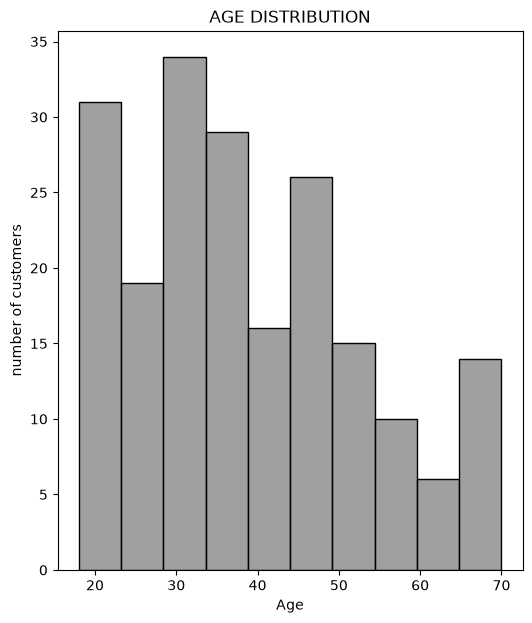

In [28]:
plt.figure(figsize=(6,7))
sns.histplot(
    data=df,
    x="Age",
    bins=10,
    color="grey"
)
plt.title("AGE DISTRIBUTION")
plt.xlabel("Age")
plt.ylabel("number of customers")
plt.savefig("../images/age_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

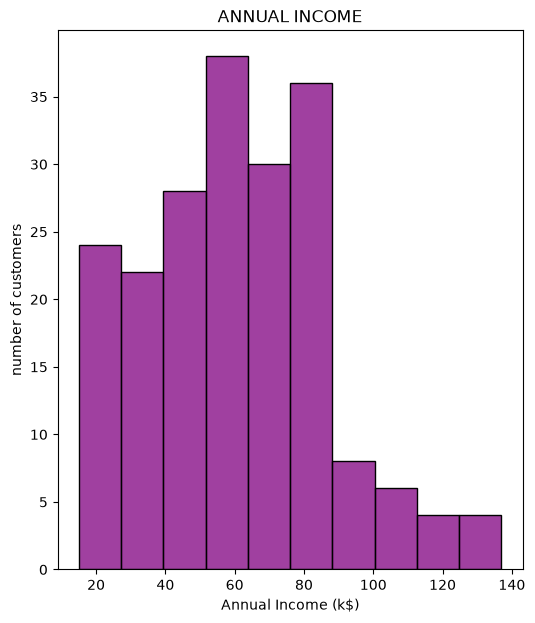

In [32]:
plt.figure(figsize=(6,7))
sns.histplot(
    data=df,
    x="Annual Income (k$)",
    bins=10,
    color="purple"
)
plt.title("ANNUAL INCOME")
plt.xlabel("Annual Income (k$)")
plt.ylabel("number of customers")
plt.savefig("../images/annual_income_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

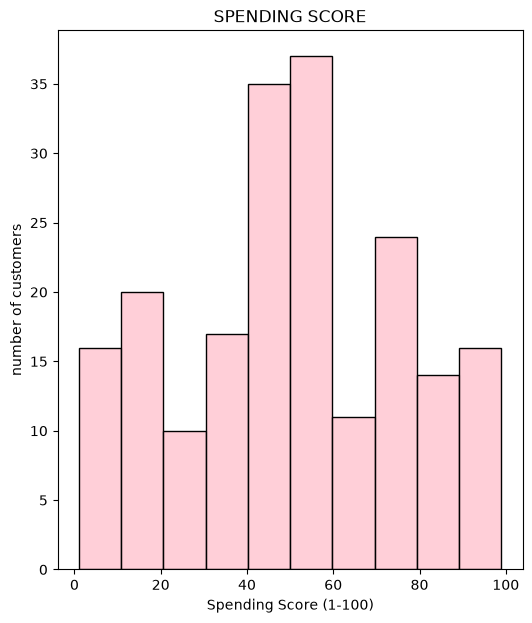

In [33]:
plt.figure(figsize=(6,7))
sns.histplot(
    data=df,
    x="Spending Score (1-100)",
    bins=10,
    color="pink"
)
plt.title("SPENDING SCORE")
plt.xlabel("Spending Score (1-100)")
plt.ylabel("number of customers")
plt.savefig("../images/spending_score_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

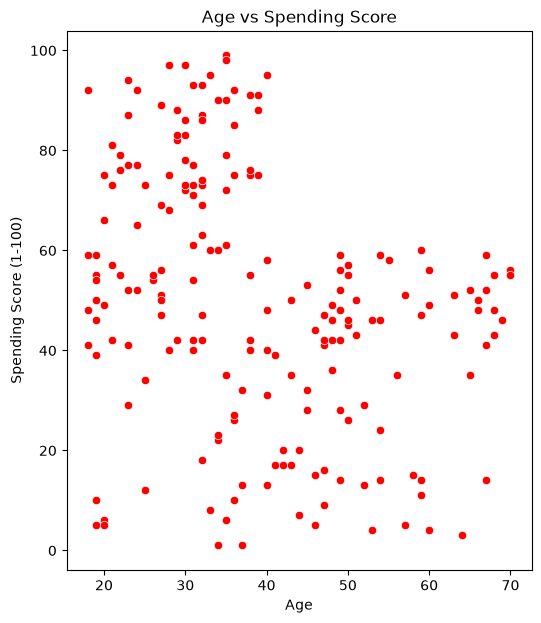

In [35]:
plt.figure(figsize=(6,7))

sns.scatterplot(
    data=df,
    x="Age",
    y="Spending Score (1-100)",
    color="red"
)

plt.title("Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.savefig("../images/age_vs_spending_score_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

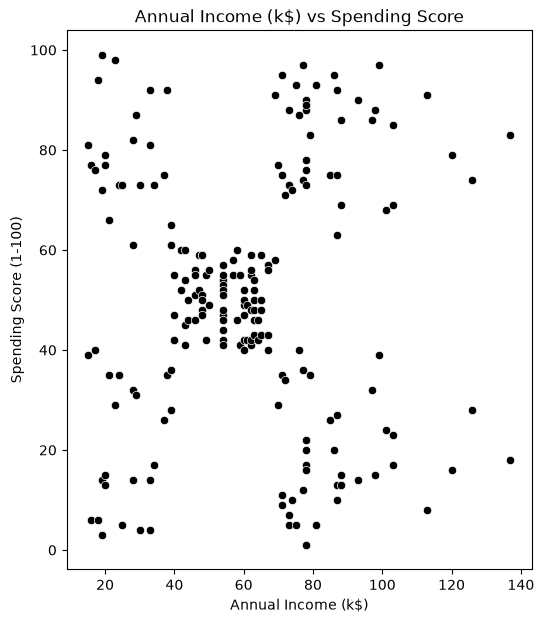

In [34]:
plt.figure(figsize=(6,7))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    color="black"
)

plt.title("Annual Income (k$) vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.savefig("../images/income_vs_spending_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

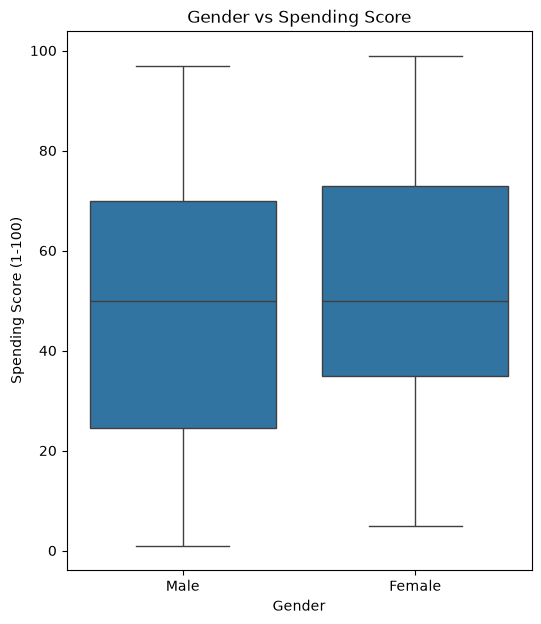

In [36]:
plt.figure(figsize=(6,7))

sns.boxplot(
    data=df,
    x="Gender",
    y="Spending Score (1-100)",
)

plt.title("Gender vs Spending Score")
plt.xlabel("Gender")
plt.ylabel("Spending Score (1-100)")
plt.savefig("../images/gender_vs_spending_score_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [19]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

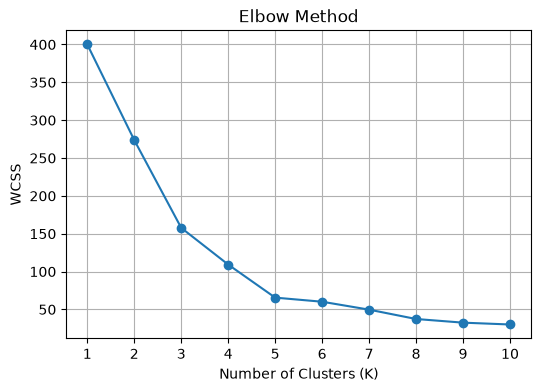

In [37]:
# K(ELBOW METHOD)

wcss=[]
for i in range(1,11): 
    Kmeans=KMeans(n_clusters=i,random_state=42)
    Kmeans.fit(X_scaled)
    wcss.append(Kmeans.inertia_)
plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(range(1,11))
plt.grid(True)

plt.savefig("../images/elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()

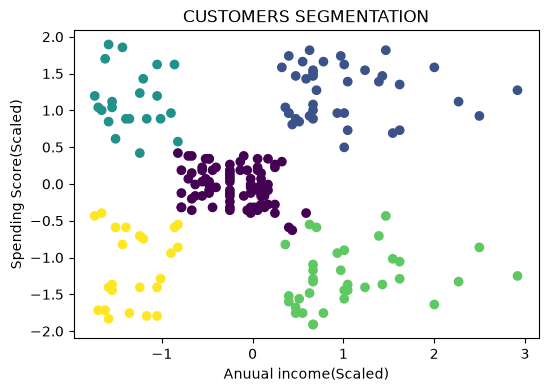

In [31]:
Kmeans=KMeans(n_clusters=5,random_state=42)
clusters=Kmeans.fit_predict(X_scaled)
df['cluster']=clusters
plt.figure(figsize=(6,4))
plt.scatter(
X_scaled[:,0],
X_scaled[:,1] ,
c=clusters,
cmap="viridis")
plt.title("CUSTOMERS SEGMENTATION")
plt.xlabel("Anuual income(Scaled)")
plt.ylabel("Spending Score(Scaled)")
plt.savefig("../images/customer_segmentation.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
# MODEL ANALYSIS
# Get cluster centers
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_scaled)
centroids = kmeans.cluster_centers_
print(centroids)

[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


In [23]:
print(df.columns)

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'cluster'],
      dtype='str')


In [24]:
# Number of customers in each cluster
cluster_counts = df["cluster"].value_counts()

print("Number of Customers in Each Cluster:")
print(cluster_counts)

Number of Customers in Each Cluster:
cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


In [25]:

cluster_summary = df.groupby("cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean()

print("Cluster Summary:")
print(cluster_summary)

Cluster Summary:
               Age  Annual Income (k$)  Spending Score (1-100)
cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043


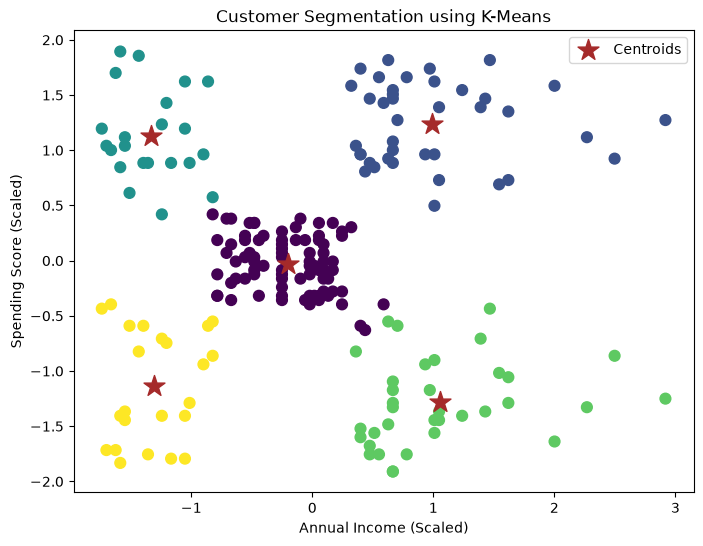

In [38]:
plt.figure(figsize=(8,6))

# Plot customers
plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=df["cluster"],
    cmap="viridis",
    s=60
)

# Plot cluster centers
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    c="brown",
    s=250,
    marker="*",
    label="Centroids"
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.legend()

plt.savefig("../images/elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
print(cluster_summary)

               Age  Annual Income (k$)  Spending Score (1-100)
cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043


# Phase 9: Interpretation

## Cluster 0
Average income and average spending customers. These customers represent regular shoppers.

## Cluster 1
High-income and high-spending customers. They are the most valuable customers and should be targeted with premium products and loyalty programs.

## Cluster 2
Low-income but high-spending customers. They respond well to discounts and promotional offers.

## Cluster 3
High-income but low-spending customers. Personalized marketing strategies may encourage them to spend more.

## Cluster 4
Low-income and low-spending customers. These customers are budget-conscious and usually spend less.

Conclusion

This project successfully applied the K-Means Clustering algorithm to segment mall customers based on their Annual Income and Spending Score. Using the Elbow Method, the optimal number of clusters was selected, and customers were grouped into five distinct segments. The results show that K-Means is an effective unsupervised machine learning technique for understanding customer behavior. These customer segments can help shopping malls create targeted marketing strategies, improve customer satisfaction, and increase business growth.